# CPM y PERT en Python
Este notebook contiene una serie de ejercicios resueltos para aplicar los métodos **CPM (Critical Path Method)** y **PERT (Program Evaluation and Review Technique)**.

Incluye:
1. CPM básico
2. PERT con tiempos esperados
3. Varianza y desviación estándar (PERT avanzado)
4. Probabilidad de terminar en una fecha límite
5. Proyecto aleatorio con grafo


## Ejemplo 1 – CPM básico con actividades
Dado el proyecto con actividades y duraciones, calcular el **camino crítico** y la duración total.

| Actividad | Duración (días) | Predecesoras |
| --------- | --------------- | ------------ |
| A         | 3               | –            |
| B         | 2               | A            |
| C         | 4               | A            |
| D         | 2               | B, C         |
| E         | 3               | D            |


In [10]:
import networkx as nx

# Definimos actividades con duraciones
activities = {
    "A": 3,
    "B": 2,
    "C": 4,
    "D": 2,
    "E": 3,
}

dependencies = {
    "A": [],
    "B": ["A"],
    "C": ["A"],
    "D": ["B", "C"],
    "E": ["D"]
}

G = nx.DiGraph()
for task, preds in dependencies.items():
    for p in preds:
        G.add_edge(p, task, weight=activities[task])

critical_path = nx.dag_longest_path(G, weight="weight")
critical_path_length = nx.dag_longest_path_length(G, weight="weight")

print("Camino crítico:", critical_path)
print("Duración total del proyecto:", critical_path_length, "días")

Camino crítico: ['A', 'C', 'D', 'E']
Duración total del proyecto: 9 días


## Ejemplo 2 – PERT con tiempos esperados
Para el mismo proyecto, ahora cada actividad tiene tres estimaciones de tiempo (optimista, más probable y pesimista):

| Actividad | To | Tm | Tp | Predecesoras |
| --------- | -- | -- | -- | ------------ |
| A         | 2  | 3  | 4  | –            |
| B         | 1  | 2  | 3  | A            |
| C         | 3  | 4  | 7  | A            |
| D         | 1  | 2  | 3  | B, C         |
| E         | 2  | 3  | 4  | D            |


Calcular el tiempo esperado de cada actividad y el camino crítico.


In [26]:
import networkx as nx
# Datos de actividades con tiempos (To, Tm, Tp)
activities = {
    "A": (2, 3, 4),
    "B": (1, 2, 3),
    "C": (3, 4, 7),
    "D": (1, 2, 3),
    "E": (2, 3, 4)
}
dependencies = {
    "A": [],
    "B": ["A"],
    "C": ["A"],
    "D": ["B", "C"],
    "E": ["D"]
}

#expected_times = {a: (t[0] + 4*t[1] + t[2]) / 6 for a, t in activities.items()}
expected_times = {} # diccionario vacio

for a, t in activities.items():
    #print(a, t) # a = key. t = value
    expected_times[a] = (t[0] + 4*t[1] + t[2]) / 6



G = nx.DiGraph()
for task, preds in dependencies.items():
    for p in preds:
        G.add_edge(p, task, weight=expected_times[task])

critical_path = nx.dag_longest_path(G, weight="weight")
critical_path_length = nx.dag_longest_path_length(G, weight="weight")

print("Tiempos esperados:", expected_times)
print("Camino crítico:", critical_path)
print("Duración total esperada:", critical_path_length, "días")

Tiempos esperados: {'A': 3.0, 'B': 2.0, 'C': 4.333333333333333, 'D': 2.0, 'E': 3.0}
Camino crítico: ['A', 'C', 'D', 'E']
Duración total esperada: 9.333333333333332 días


In [8]:
#### diccionarios
D = {}
print(D)
D['hola'] = 'hello'
print(D)
D['hola'] = 'bonjour'
print(D)
D['adios'] = 'au revoir'

print(D)

{}
{'hola': 'hello'}
{'hola': 'bonjour'}
{'hola': 'bonjour', 'adios': 'au revoir'}


## Ejemplo 3 – Variabilidad del proyecto (PERT avanzado)
Con los mismos datos de PERT:

Calcular la varianza y desviación estándar del proyecto.


In [12]:
#variances = {a: ((t[2] - t[0]) / 6) ** 2 for a, t in activities.items()}
variances = {}  # empty dictionnary
for a, t in activities.items():
    variances[a] = ((t[2] - t[0]) / 6) ** 2
#variances = {'A' : 1.2, 'B' : 2.25, 'C': 1.11111 }
#project_variance = sum(variances[a] for a in critical_path)
project_variance = 0
for a in critical_path:
    project_variance += variances[a]

project_std_dev = project_variance ** 0.5

print("Varianzas:", variances)
print("Varianza total del proyecto:", project_variance)
print("Desviación estándar:", project_std_dev)

Varianzas: {'A': 0.1111111111111111, 'B': 0.1111111111111111, 'C': 0.4444444444444444, 'D': 0.1111111111111111, 'E': 0.1111111111111111}
Varianza total del proyecto: 0.7777777777777779
Desviación estándar: 0.881917103688197


## Ejemplo 4 – Probabilidad de terminar en una fecha límite
Si el cliente pide terminar en 12 días, calcular la probabilidad de cumplirlo usando distribución normal:

(Usar distribución normal para calcular la probabilidad de cumplir un deadline.)


In [15]:
import scipy.stats as st

deadline = 12
Z = (deadline - critical_path_length) / project_std_dev
prob = st.norm.cdf(Z) # cumulative distribution function

print(f"Probabilidad de terminar en {deadline} días o menos: {prob:.4%}")

Probabilidad de terminar en 12 días o menos: 99.8752%


## Ejemplo 5 – Proyecto aleatorio con grafo

Escribe un programa que:

Genere aleatoriamente un conjunto de 5–10 actividades con dependencias y duraciones.

Calcule el camino crítico y la duración total.

Dibuje el grafo del proyecto con matplotlib.


Actividades: {'A': 5, 'B': 10, 'C': 5, 'D': 10, 'E': 4, 'F': 9}
Dependencias: {'A': [], 'B': ['A'], 'C': ['B'], 'D': ['A'], 'E': ['A'], 'F': ['A']}
Camino crítico: ['A', 'B', 'C']
Duración total: 15


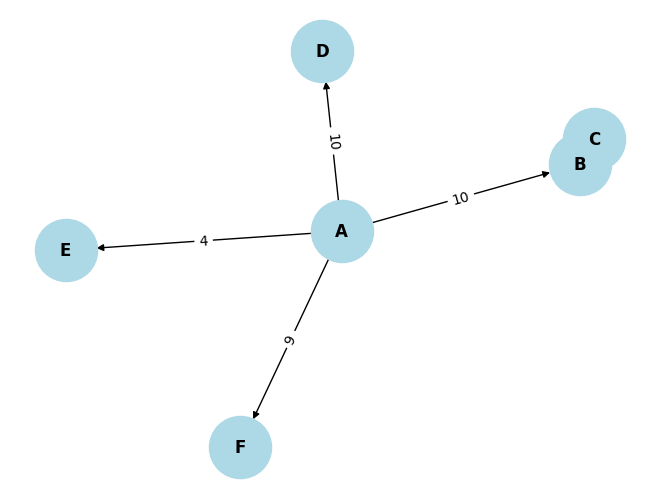

In [25]:
import random
import matplotlib.pyplot as plt

# Generar actividades aleatorias
n = 6 # A - F
#print(chr(65)) # A
#print(chr(66)) # B

activities = {chr(65+i): random.randint(1, 10) for i in range(n)} # diccionario actividad : duración

# Dependencias simples: cada actividad (excepto la primera) depende de alguna anterior
dependencies = {}
for i, act in enumerate(activities.keys()):
    if i == 0:
        dependencies[act] = [] # actividad A no tiene predecesor
    else:
        dependencies[act] = [random.choice(list(activities.keys())[:i])]

# Crear grafo
G = nx.DiGraph()
for task, preds in dependencies.items():
    for p in preds:
        G.add_edge(p, task, weight=activities[task])

# Calcular camino crítico
critical_path = nx.dag_longest_path(G, weight="weight")
critical_path_length = nx.dag_longest_path_length(G, weight="weight")

print("Actividades:", activities)
print("Dependencias:", dependencies)
print("Camino crítico:", critical_path)
print("Duración total:", critical_path_length)

# Dibujar grafo
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=12, font_weight='bold')
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
plt.show()

# Ejercicios

## Integrantes

In [ ]:
# Integrantes
# 1.
# 2.
# 3.
# 4.

## Ejercicio 1 – Proyecto de software (CPM básico)

Un proyecto de software tiene las siguientes actividades y duraciones:

| Actividad                     | Duración | Predecesoras |
| ----------------------------- | -------- | ------------ |
| A – Recolección de requisitos | 4        | –            |
| B – Diseño de sistema         | 3        | A            |
| C – Programación módulo 1     | 6        | B            |
| D – Programación módulo 2     | 5        | B            |
| E – Pruebas integradas        | 4        | C, D         |

Tareas:

1. Representar el proyecto como un grafo en Python.

2. Calcular el camino crítico y la duración total usando networkx.

In [ ]:
# Ejercicio 1

## Ejercicio 2 – Construcción de una casa (PERT)

Cada actividad tiene tres estimaciones de tiempo (optimista, probable, pesimista):

| Act                          | To | Tm | Tp | Predecesoras |
| ---------------------------- | -- | -- | -- | ------------ |
| A – Excavación               | 2  | 4  | 6  | –            |
| B – Cimientos                | 3  | 5  | 7  | A            |
| C – Paredes                  | 5  | 8  | 11 | B            |
| D – Techo                    | 2  | 4  | 8  | C            |
| E – Instalaciones eléctricas | 3  | 6  | 9  | C            |
| F – Pintura                  | 2  | 3  | 5  | D, E         |

Tareas:

1. Calcular el tiempo esperado de cada actividad con la fórmula PERT.

2. Encontrar el camino crítico esperado.

In [ ]:
# Ejercicio 2

## Ejercicio 3 – Evento universitario (PERT avanzado)

Para organizar un congreso, se tiene:

| Act                           | To | Tm | Tp | Predecesoras |
| ----------------------------- | -- | -- | -- | ------------ |
| A – Reserva del auditorio     | 1  | 2  | 3  | –            |
| B – Invitación de ponentes    | 2  | 4  | 8  | A            |
| C – Diseño de publicidad      | 1  | 2  | 4  | A            |
| D – Difusión                  | 2  | 3  | 6  | C            |
| E – Registro de participantes | 3  | 5  | 7  | D            |
| F – Montaje del evento        | 2  | 3  | 5  | B, E         |

Tareas:

1. Calcular el tiempo esperado y varianza de cada actividad.

2. Hallar la varianza total del proyecto.

3. Calcular la desviación estándar del tiempo final.

In [ ]:
# Ejercicio 3

## Ejercicio 4 – Lanzamiento de un producto (Probabilidad PERT)

Se tienen los datos:

| Act                       | To | Tm | Tp | Predecesoras |
| ------------------------- | -- | -- | -- | ------------ |
| A – Estudio de mercado    | 1  | 2  | 3  | –            |
| B – Diseño del prototipo  | 2  | 3  | 5  | A            |
| C – Pruebas del prototipo | 3  | 5  | 7  | B            |
| D – Marketing             | 2  | 4  | 6  | A            |
| E – Lanzamiento           | 1  | 2  | 4  | C, D         |

Tareas:

1. Calcular la duración esperada del proyecto.

2. Su desviación estándar.

3. Si la gerencia fija 15 días como plazo límite, calcular la probabilidad de cumplirlo usando distribución normal.

In [ ]:
# Ejercicio 4